In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import cell2location

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs


/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
/home/aakanksha/.local/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numb

In [2]:
results_folder = '../intermediate_data/cell2location_test_res/'

In [3]:
# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f'{results_folder}/reference_signatures'
run_name = f'{results_folder}/cell2location_map'

Reading single cell data

In [19]:
# Read data
adata_ref = sc.read_h5ad('../intermediate_data/processed_sces/pbmc8k.h5ad')

/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


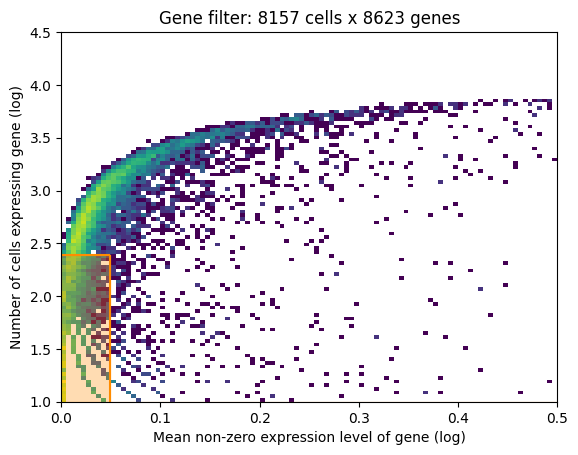

In [20]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

# filter the object
adata_ref = adata_ref[:, selected].copy()

In [6]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(adata=adata_ref,labels_key='cell_type',batch_key='Sample')

/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [7]:
# create the regression model
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref)

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.0.4.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Sample',
│   'labels_key': 'cell_type',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 8157  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   6   │
│          n_vars          │ 8623  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                   batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Sample'] │   pbmc8k   │          0          │
└─────────────────────┴────────────┴─────────────────────┘

                      labels State Registry                       
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃   Categories    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell_type'] │     B cells     │          0          │
│                        │ Dendritic cells │          1          │
│                        │    Monocytes    │          2          │
│                        │    NK cells     │          3          │
│                        │   Progenitors   │          4          │
│                        │     T cells     │          5          │
└────────────────────────┴─────────────────┴─────────────────────┘

In [8]:
mod.train(max_epochs=1000, use_gpu=False)

/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/scvi/train/_trainrunner.py:76: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  accelerator, lightning_devices, device = parse_device_args(
/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/anaconda3/envs/cell2loc_env/lib/pyth ...
  rank_zero_warn(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using

Epoch 1000/1000: 100%|██████████████████████████████████████████| 1000/1000 [1:22:21<00:00,  4.93s/it, v_num=1, elbo_train=3.31e+7]

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 1000/1000: 100%|██████████████████████████████████████████| 1000/1000 [1:22:21<00:00,  4.94s/it, v_num=1, elbo_train=3.31e+7]


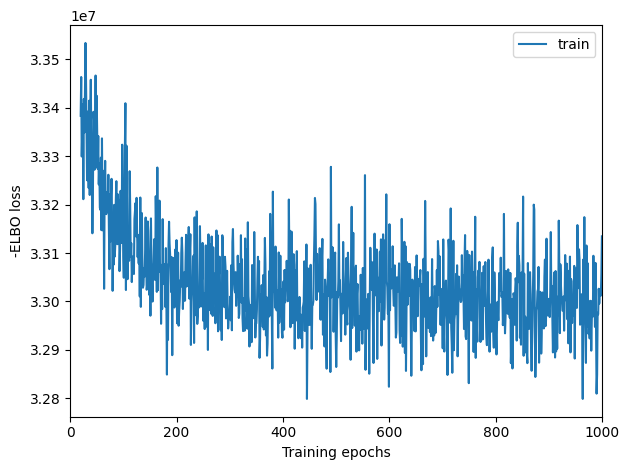

In [9]:
mod.plot_history(20)

In [10]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_ref = mod.export_posterior(
    adata_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 2500, 'use_gpu': False}
)

# Save model
mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
adata_file = f"{ref_run_name}/sc_cell2location_model.h5ad"
adata_ref.write(adata_file)
adata_file

/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/scvi/model/base/_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


Sampling local variables, batch:   0%|   | 0/4 [00:00<?, ?it/s]
Sampling global variables, sample: 100%|█| 999/999 [02:45<00:00


'../intermediate_data/cell2location_test_res//reference_signatures/sc_cell2location_model.h5ad'

In [11]:
adata_ref = mod.export_posterior(
    adata_ref, 
    #use_quantiles=True,
    # choose quantiles
    #add_to_obsm=["q05","q50", "q95", "q0001"],
    sample_kwargs={'batch_size': 2500, 'use_gpu': False}
)

/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/scvi/model/base/_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


Sampling local variables, batch:   0%|   | 0/4 [00:00<?, ?it/s]
Sampling global variables, sample: 100%|█| 999/999 [02:05<00:00


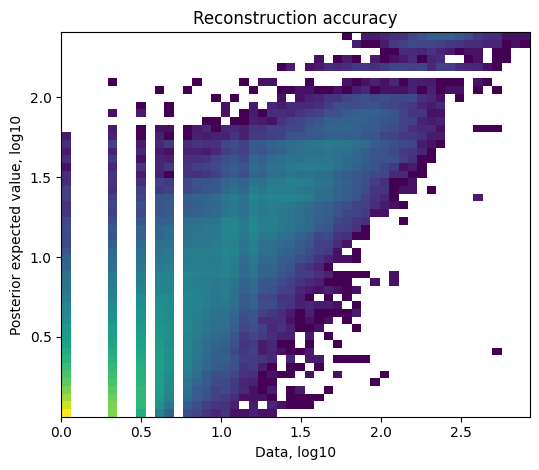

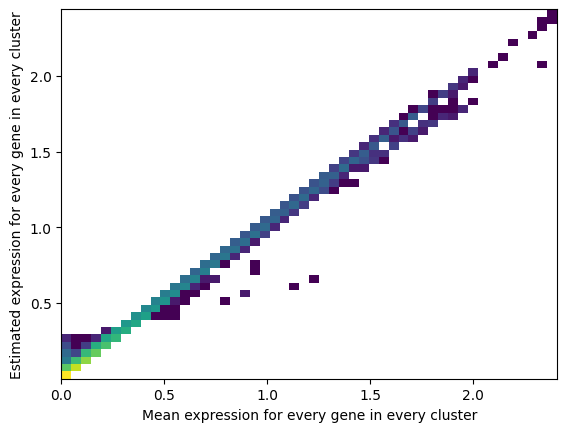

In [12]:
mod.plot_QC()

In [13]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,B cells,Dendritic cells,Monocytes,NK cells,Progenitors
FAM41C,0.050157,0.082453,0.031967,0.043448,0.111424
NOC2L,0.162061,0.420474,0.132837,0.245503,0.480542
HES4,0.006077,0.083317,0.282295,0.011334,0.077819
ISG15,0.295214,0.753568,0.828476,0.565512,0.273211
TNFRSF18,0.011717,0.020379,0.007015,0.207499,0.078214


Cell2Location Spatial Mapping

In [56]:
# Loading the psedobulk data
adata_viz = sc.read_h5ad('../intermediate_data/bootstraped_pseudobulks/pbmc_pseudobulks.h5ad')
adata_viz.var.index.name = 'SYMBOL'

In [57]:
import numpy as np
adata_viz.obsm['spatial'] = np.array(adata_viz.obsm['spatial'])
# Replace NaNs with 0
adata_viz.X = np.nan_to_num(adata_viz.X, nan=0.0)

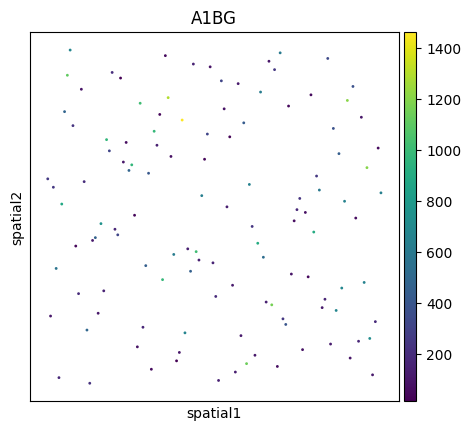

In [60]:
sc.pl.spatial(adata_viz, color='A1BG', gene_symbols='SYMBOL', spot_size=1)

In [61]:
adata_viz.obs['sample'] = adata_viz.obs.index.str.split('_').str[0]

In [62]:
print(adata_viz.obs.head())

                 dataset Bootstrap   x   y sample_id  sample
pbmc3k_boot1.Raw  pbmc3k         1  94  82  sample01  pbmc3k
pbmc4k_boot1.Raw  pbmc4k         1  71  27  sample01  pbmc4k
pbmc6k_boot1.Raw  pbmc6k         1  51  72  sample01  pbmc6k
pbmc8k_boot1.Raw  pbmc8k         1  76  70  sample01  pbmc8k
pbmc3k_boot2.Raw  pbmc3k         2  64  22  sample01  pbmc3k


In [63]:
# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(adata_viz.var_names, inf_aver.index)
adata_viz = adata_viz[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_viz, batch_key="sample")

In [64]:
# create and train the model (Max number of cells= 2000 and detection alpha=20)
mod = cell2location.models.Cell2location(
    adata_viz, cell_state_df=inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=2000,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=100
)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.0.4.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   4   │
│         n_cells          │  120  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 8623  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                   batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │   pbmc3k   │          0          │
│                     │   pbmc4k   │          1          │
│                     │   pbmc6k   │          2          │
│                     │   pbmc8k   │          3          │
└─────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/anaconda3/envs/cell2loc_env/lib/pyth ...
  rank_zero_warn(
/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/scvi/train/_trainrunner.py:76: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is 

Epoch 30000/30000: 100%|█| 30000/30000 [40:29<00:00, 12.25it/s,

`Trainer.fit` stopped: `max_epochs=30000` reached.


Epoch 30000/30000: 100%|█| 30000/30000 [40:29<00:00, 12.35it/s,


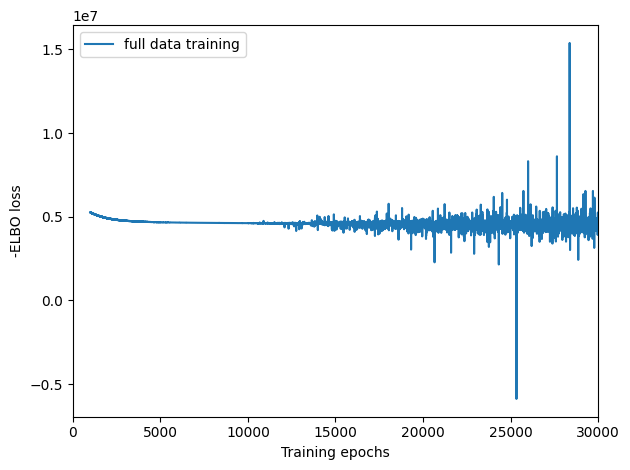

In [65]:
mod.train(max_epochs=30000,
          # train using full data (batch_size=None)
          batch_size=None,
          # use all data points in training because
          # we need to estimate cell abundance at all locations
          train_size=1,
          use_gpu=False,
         )

# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(1000)
plt.legend(labels=['full data training']);

In [66]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_viz = mod.export_posterior(
    adata_viz, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs, 'use_gpu': False}
)

# Save model
mod.save(f"{run_name}", overwrite=True)

# mod = cell2location.models.Cell2location.load(f"{run_name}", adata_vis)

# Save anndata object with results
adata_file = f"{run_name}/sp_bootstrap.h5ad"
adata_viz.write(adata_file)
adata_file

/home/aakanksha/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/scvi/model/base/_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


Sampling local variables, batch: 100%|█| 1/1 [00:11<00:00, 11.9
Sampling global variables, sample: 100%|█| 999/999 [00:13<00:00


'../intermediate_data/cell2location_test_res//cell2location_map/sp_bootstrap.h5ad'

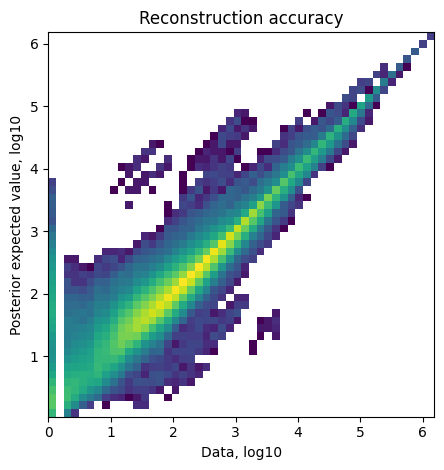

In [67]:
mod.plot_QC()

In [69]:
adata_viz

AnnData object with n_obs × n_vars = 120 × 8623
    obs: 'dataset', 'Bootstrap', 'x', 'y', 'sample_id', 'sample', '_indices', '_scvi_batch', '_scvi_labels', 'total RNA counts'
    uns: 'X_name', '_scvi_uuid', '_scvi_manager_uuid', 'mod'
    obsm: 'spatial', 'means_cell_abundance_w_sf', 'stds_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf'

In [70]:
means = adata_viz.obsm['means_cell_abundance_w_sf']
adata_viz.obsm['props_cell_abundance'] = means.div(means.sum(axis=1), axis=0)

In [71]:
means

,meanscell_abundance_w_sf_B cells,meanscell_abundance_w_sf_Dendritic cells,meanscell_abundance_w_sf_Monocytes,meanscell_abundance_w_sf_NK cells,meanscell_abundance_w_sf_Progenitors,meanscell_abundance_w_sf_T cells
pbmc3k_boot1.Raw,18.711666,10.703701,566.576294,83.330208,0.415445,501.586792
pbmc4k_boot1.Raw,876.736389,12.181725,327.116028,126.333755,1.882220,1966.146240
pbmc6k_boot1.Raw,274.591614,34.930149,861.819824,238.896545,1.122642,1306.987915
pbmc8k_boot1.Raw,1240.090210,11.562196,462.176849,54.820835,3.235971,3179.708984
pbmc3k_boot2.Raw,326.277161,35.852802,613.828308,249.300262,5.911040,658.810791
...,...,...,...,...,...,...
pbmc8k_boot29.Raw,166.410599,11.247859,1325.172729,300.091095,2.662144,2939.063965
pbmc3k_boot30.Raw,289.207886,39.979534,721.475403,101.181404,4.874398,54.075039
pbmc4k_boot30.Raw,731.549500,11.332797,471.536804,257.026794,0.783009,1027.070557
pbmc6k_boot30.Raw,489.969208,43.171108,750.136780,236.085785,1.473413,2285.375000


In [72]:
means = adata_viz.obsm['means_cell_abundance_w_sf']
props = means.div(means.sum(axis=1), axis=0)
adata_viz.obsm['props_cell_abundance'] = props

In [73]:
props

,meanscell_abundance_w_sf_B cells,meanscell_abundance_w_sf_Dendritic cells,meanscell_abundance_w_sf_Monocytes,meanscell_abundance_w_sf_NK cells,meanscell_abundance_w_sf_Progenitors,meanscell_abundance_w_sf_T cells
pbmc3k_boot1.Raw,0.015840,0.009061,0.479611,0.070540,0.000352,0.424597
pbmc4k_boot1.Raw,0.264843,0.003680,0.098815,0.038163,0.000569,0.593931
pbmc6k_boot1.Raw,0.101014,0.012850,0.317038,0.087883,0.000413,0.480802
pbmc8k_boot1.Raw,0.250443,0.002335,0.093339,0.011071,0.000654,0.642159
pbmc3k_boot2.Raw,0.172635,0.018970,0.324780,0.131906,0.003128,0.348581
...,...,...,...,...,...,...
pbmc8k_boot29.Raw,0.035073,0.002371,0.279298,0.063248,0.000561,0.619448
pbmc3k_boot30.Raw,0.238858,0.033019,0.595870,0.083566,0.004026,0.044661
pbmc4k_boot30.Raw,0.292702,0.004534,0.188668,0.102840,0.000313,0.410943
pbmc6k_boot30.Raw,0.128729,0.011342,0.197082,0.062026,0.000387,0.600433
